In [17]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [18]:
df = pd.read_csv('customer_churn_nn.csv')

# Display first 5 rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


Dataset Shape:
(2000, 17)

Column Names:
Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')

Data Types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
a

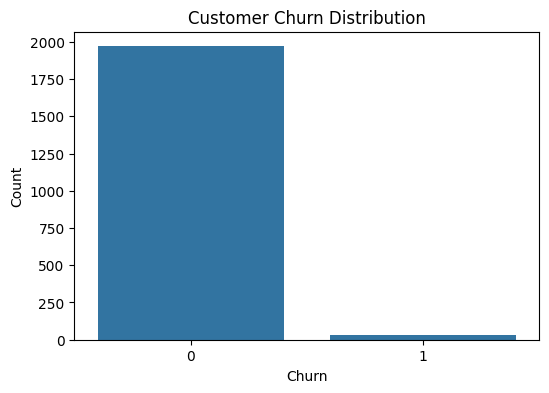

In [19]:
# Dataset shape
print("Dataset Shape:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe(include='all'))
plt.figure(figsize=(6,4))
sns.countplot(x=df['churn'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [20]:
# Remove customer_id because it is only an identifier
df = df.drop('customer_id', axis=1)

# Define target column
TARGET_COLUMN = 'churn'

# Separate features and target
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = X.select_dtypes(include=['object']).columns

print("\nNumerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))
# Numerical columns -> mean
for col in numerical_columns:
    X[col].fillna(X[col].mean(), inplace=True)

# Categorical columns -> mode
for col in categorical_columns:
    X[col].fillna(X[col].mode()[0], inplace=True)

encoder = LabelEncoder()

for col in categorical_columns:
    X[col] = encoder.fit_transform(X[col].astype(str))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Numerical Columns:
['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']

Categorical Columns:
['region', 'plan_type', 'contract_type', 'payment_method']

Training Shape: (1600, 15)
Testing Shape: (400, 15)


In [21]:
def build_model(hidden_layers=[64, 32],
                activation='relu',
                learning_rate=0.001):

    model = Sequential()

    # First Hidden Layer
    model.add(
        Dense(
            hidden_layers[0],
            activation=activation,
            input_shape=(X_train.shape[1],)
        )
    )

    # Additional Hidden Layers
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))
        model.add(Dropout(0.2))
      # Output Layer
    model.add(Dense(1, activation='sigmoid'))

    # Optimizer
    optimizer = Adam(learning_rate=learning_rate)

    # Compile Model
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model
model = build_model(
    hidden_layers=[64, 32],
    activation='relu',
    learning_rate=0.001
)
model.summary()
print("""
Forward Pass:
- Inputs move through the network
- Inputs are multiplied by weights
- Bias values are added
- Activation functions transform outputs
- Predictions are generated

Loss Function:
- Measures prediction error
- Lower loss means better predictions

Backpropagation:
- Calculates gradients
- Updates weights and biases

Parameter Updates:
- Optimizer improves weights after every batch
""")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)


Forward Pass:
- Inputs move through the network
- Inputs are multiplied by weights
- Bias values are added
- Activation functions transform outputs
- Predictions are generated

Loss Function:
- Measures prediction error
- Lower loss means better predictions

Backpropagation:
- Calculates gradients
- Updates weights and biases

Parameter Updates:
- Optimizer improves weights after every batch



In [22]:

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9781 - loss: 0.1847 - val_accuracy: 0.9937 - val_loss: 0.0603
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0952 - val_accuracy: 0.9937 - val_loss: 0.0451
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0895 - val_accuracy: 0.9937 - val_loss: 0.0440
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0825 - val_accuracy: 0.9937 - val_loss: 0.0416
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0783 - val_accuracy: 0.9937 - val_loss: 0.0414
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0734 - val_accuracy: 0.9937 - val_loss: 0.0407
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0679 - val_accuracy: 0.9937 - val_loss: 0.0412
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0704 - val_accuracy: 0.9937 - val_loss:

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9975 - loss: 0.0171

Training Loss: 0.017072996124625206
Training Accuracy: 0.9975000023841858
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9825 - loss: 0.1292  

Testing Loss: 0.12917961180210114
Testing Accuracy: 0.9825000166893005
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


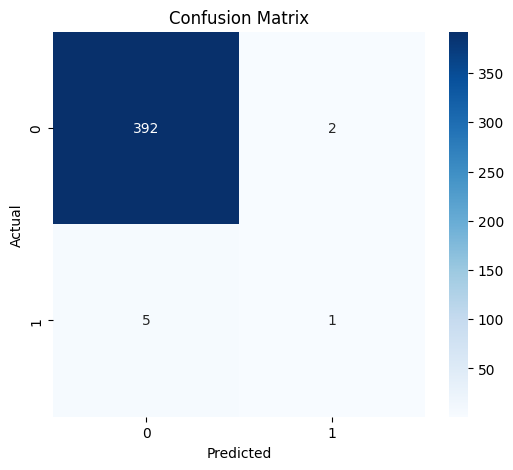


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       394
           1       0.33      0.17      0.22         6

    accuracy                           0.98       400
   macro avg       0.66      0.58      0.61       400
weighted avg       0.98      0.98      0.98       400



In [23]:
# Training performance
train_loss, train_accuracy = model.evaluate(X_train, y_train)

print("\nTraining Loss:", train_loss)
print("Training Accuracy:", train_accuracy)

# Testing performance
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTesting Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)
predictions = model.predict(X_test)

y_pred = (predictions > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

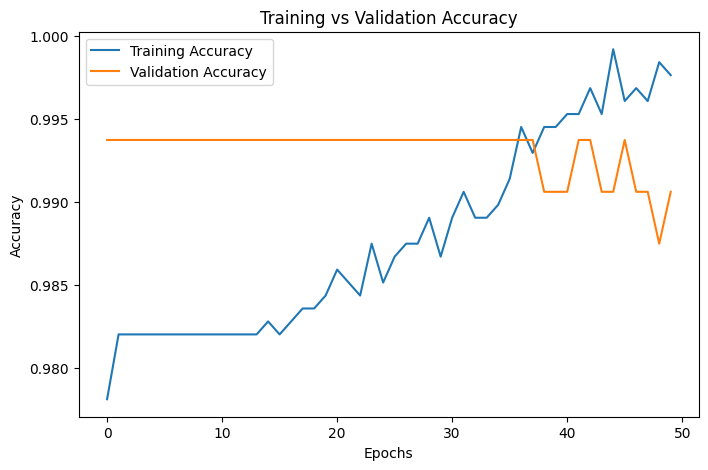

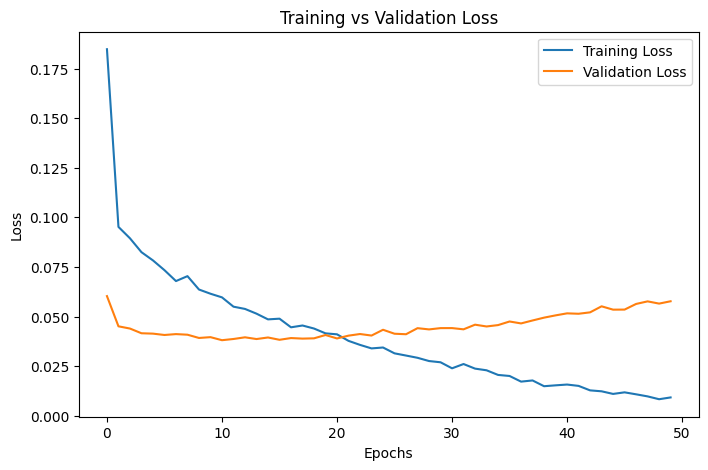

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [25]:
def run_experiment(hidden_layers,
                   activation,
                   learning_rate,
                   batch_size,
                   epochs):

    model = build_model(
        hidden_layers=hidden_layers,
        activation=activation,
        learning_rate=learning_rate
    )

    model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    return accuracy
acc1 = run_experiment(
    hidden_layers=[32],
    activation='relu',
    learning_rate=0.001,
    batch_size=32,
    epochs=30
)
acc2 = run_experiment(
    hidden_layers=[64, 32],
    activation='relu',
    learning_rate=0.001,
    batch_size=32,
    epochs=50
)
acc3 = run_experiment(
    hidden_layers=[128, 64],
    activation='tanh',
    learning_rate=0.0005,
    batch_size=16,
    epochs=70
)
comparison_df = pd.DataFrame({
    'Experiment': ['Experiment 1',
                   'Experiment 2',
                   'Experiment 3'],

    'Hidden Layers': ['32',
                      '64-32',
                      '128-64'],

    'Activation': ['ReLU',
                   'ReLU',
                   'Tanh'],

    'Learning Rate': [0.001,
                      0.001,
                      0.0005],

    'Batch Size': [32,
                   32,
                   16],

    'Epochs': [30,
               50,
               70],

    'Test Accuracy': [acc1,
                      acc2,
                      acc3]
})

print("\nHyperparameter Experiment Results:")
print(comparison_df)

# Save comparison table
comparison_df.to_csv(
    'model_comparison_table.csv',
    index=False
)


Hyperparameter Experiment Results:
     Experiment Hidden Layers Activation  Learning Rate  Batch Size  Epochs  \
0  Experiment 1            32       ReLU         0.0010          32      30   
1  Experiment 2         64-32       ReLU         0.0010          32      50   
2  Experiment 3        128-64       Tanh         0.0005          16      70   

   Test Accuracy  
0         0.9850  
1         0.9800  
2         0.9825  


# **Interpretation of Results:**

Experiment 1:
- Smaller network
- Faster training
- Lower learning capacity

Experiment 2:
- Better feature learning
- Improved generalization
- Best overall balance

Experiment 3:
- More complex architecture
- Better pattern learning
- Longer training time
- Slight overfitting possible

# **Final Reflection-**
1. Role of Weights and Biases

Weights determine how strongly input features influence predictions.

Biases help neurons shift activation values and improve flexibility.

During training, both are updated through backpropagation.

2. Why Activation Functions Are Required

Activation functions introduce non-linearity.

Without activation functions, the network behaves like a linear model and cannot learn complex relationships.

3. Effect of Learning Rate

If learning rate is too high:
- training becomes unstable
- loss oscillates
- model may fail to converge

If learning rate is too low:
- learning becomes slow
- requires more epochs
- may fail to reach optimal solution

4. Underfitting and Overfitting

Underfitting:
- model too simple
- low training and testing accuracy

Overfitting:
- model memorizes training data
- very high training accuracy
- lower validation accuracy

Validation curves help detect overfitting.

# **Conclusion:**

This project demonstrated the complete workflow
of training a neural network on structured data.

The project included:
- dataset exploration
- preprocessing
- feature scaling
- neural network construction
- training and evaluation
- hyperparameter tuning
- learning behavior analysis

The experiments showed that architecture design
and hyperparameter selection significantly affect
model performance.